In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pdb # use 'pdb.set_trace()' where you want to see

torch.manual_seed(2222)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        n_input = 2
        n_output = 1
        n_nodes = 30

        self.hidden_layer1 = nn.Linear(n_input,n_nodes)
        nn.init.xavier_uniform_(self.hidden_layer1.weight)
        nn.init.normal_(self.hidden_layer1.bias)

        self.hidden_layer2 = nn.Linear(n_nodes,n_nodes)
        nn.init.xavier_uniform_(self.hidden_layer2.weight)
        nn.init.normal_(self.hidden_layer2.bias)

        self.hidden_layer3 = nn.Linear(n_nodes,n_nodes)
        nn.init.xavier_uniform_(self.hidden_layer3.weight)
        nn.init.normal_(self.hidden_layer3.bias)

        self.hidden_layer4 = nn.Linear(n_nodes,n_nodes)
        nn.init.xavier_uniform_(self.hidden_layer4.weight)
        nn.init.normal_(self.hidden_layer4.bias)

        self.hidden_layer5 = nn.Linear(n_nodes,n_nodes)
        nn.init.xavier_uniform_(self.hidden_layer5.weight)
        nn.init.normal_(self.hidden_layer5.bias)

        self.hidden_layer6 = nn.Linear(n_nodes,n_nodes)
        nn.init.xavier_uniform_(self.hidden_layer6.weight)
        nn.init.normal_(self.hidden_layer6.bias)

        self.output_layer = nn.Linear(n_nodes, n_output)
        nn.init.xavier_uniform_(self.output_layer.weight)
        nn.init.normal_(self.output_layer.bias)

    def forward(self, x,y):
        inputs = torch.cat([x,y],axis=1)

        layer1_out = torch.tanh(self.hidden_layer1(inputs))
        layer2_out = torch.tanh(self.hidden_layer2(layer1_out))
        layer3_out = torch.tanh(self.hidden_layer3(layer2_out))
        layer4_out = torch.tanh(self.hidden_layer4(layer3_out))
        layer5_out = torch.tanh(self.hidden_layer5(layer4_out))
        layer6_out = torch.tanh(self.hidden_layer6(layer5_out))

        output = self.output_layer(layer6_out) ## For regression, no activation is used in output layer
        return output

In [ ]:
def pinnLoss(x,y, mse, net_u, net_v):

    u = net_u(x,y)
    v = net_v(x,y)

    # E = 1
    # nu = 0.3

    # lmbd = E * nu/((1+nu)*(1-2*nu))
    # mu = E/(2*(1+nu))

    #Alu
    # lmbd = 0.504
    # mu = 0.259

    #Steel
    lmbd = 1.076
    mu = 0.779

    #Copper
    # lmbd = 0.854
    # mu = 0.44

    u_x = torch.autograd.grad(u.sum(), x, create_graph=True)[0]
    u_y = torch.autograd.grad(u.sum(), y, create_graph=True)[0]
    v_x = torch.autograd.grad(v.sum(), x, create_graph=True)[0]
    v_y = torch.autograd.grad(v.sum(), y, create_graph=True)[0]

    exx = u_x
    eyy = v_y
    exy = 1/2*(u_y + v_x)

    sxx = (lmbd+2*mu)*exx + lmbd*eyy
    syy = (lmbd+2*mu)*eyy + lmbd*exx
    sxy = 2*mu*exy

    sxx_x = torch.autograd.grad(sxx.sum(), x, create_graph=True)[0]
    sxy_x = torch.autograd.grad(sxy.sum(), x, create_graph=True)[0]
    sxy_y = torch.autograd.grad(sxy.sum(), y, create_graph=True)[0]
    syy_y = torch.autograd.grad(syy.sum(), y, create_graph=True)[0]

    Fx = (sxx_x + sxy_y)
    Fy = (sxy_x + syy_y) - 1

    mse_losspde= mse(Fx, torch.zeros_like(x)) + mse(Fy, torch.zeros_like(x))


    return mse_losspde, u, v, sxx, sxy, syy


In [ ]:
def dataPoints(x0,y0,x1,y1,nx,ny,densBnd):

    x = np.linspace(x0,x1,num = nx)
    y = np.linspace(y0,y1,num = ny)

    X, Y = np.meshgrid(x,y)

    xi = X[1:-1,1:-1].reshape(-1,1)
    yi = Y[1:-1,1:-1].reshape(-1,1)

    xb = np.linspace(x0,x1,num = densBnd * nx)
    yb = np.linspace(y0,y1,num = densBnd * ny)
    Xb, Yb = np.meshgrid(xb,yb)
    xb = np.hstack((Xb[:,0], Xb[-1,:],Xb[:,-1],Xb[0,:])).reshape(-1,1)
    yb = np.hstack((Yb[:,0], Yb[-1,:],Yb[:,-1],Yb[0,:])).reshape(-1,1)
    xt = np.vstack((xb,xi))
    yt = np.vstack((yb,yi))

    fig = plt.figure(figsize=(10,1.5))
    plt.scatter(xb,yb,s=2)
    plt.scatter(xi,yi,s=2)
    plt.show

    return xt, yt

In [ ]:
def boundaryPointsCantilever(x,y,x0,y0,x1,y1):

    Lx = x1 - x0
    Ly = y1 - y0

    # x = 0
    idxLeft = torch.where(x==x0)

    # x = Lx
    idxRight = torch.where(x==x1)

    # y = 0
    idxBot = torch.where(y==y0)

    # y = Ly
    idxTop = torch.where(y==y1)

    return idxLeft, idxBot, idxTop, idxRight

In [ ]:
def boundaryLoss(f, x, y, x0, y0, x1,y1, mse, net_u, net_v):

    xL = x[idxLeft].view(-1,1)
    yL = y[idxLeft].view(-1,1)
    _, u_xL, v_xl, _, _, _ = pinnLoss(xL, yL, mse, net_u, net_v)


    xT = x[idxTop].view(-1,1)
    yT = y[idxTop].view(-1,1)
    _, _, _, _, sxy_xT, syy_xT = pinnLoss(xT,yT, mse, net_u, net_v)

    xB = x[idxBot].view(-1,1)
    yB = y[idxBot].view(-1,1)
    _, _, _, _, sxy_xB, syy_xB = pinnLoss(xB,yB, mse, net_u, net_v)

    xR = x[idxRight].view(-1,1)
    yR = y[idxRight].view(-1,1)
    _, u_xr, v_xr, _, _, _ = pinnLoss(xR,yR, mse, net_u, net_v)


    net_bc_left_u_free = u_xL.view(-1,1)
    net_bc_left_v_free = v_xl.view(-1,1)

    net_bc_right_u_free = u_xr.view(-1,1)
    net_bc_right_v_free = v_xr.view(-1,1)

    net_bc_top_syy_free = syy_xT.view(-1,1)
    net_bc_top_sxy_free = sxy_xT.view(-1,1)

    net_bc_bot_syy_free = syy_xB.view(-1,1)
    net_bc_bot_sxy_free = sxy_xB.view(-1,1)


    mse_bc_left_u = mse(net_bc_left_u_free, torch.zeros_like(net_bc_left_u_free))
    mse_bc_left_v = mse(net_bc_left_v_free, torch.zeros_like(net_bc_left_u_free))

    mse_bc_right_sxx_free = mse(net_bc_right_u_free, torch.zeros_like(net_bc_right_u_free))
    mse_bc_right_sxy_free = mse(net_bc_right_v_free, torch.zeros_like(net_bc_right_v_free))

    mse_bc_top_syy = mse(net_bc_top_syy_free, f * torch.ones_like(net_bc_top_syy_free))
    mse_bc_top_sxy = mse(net_bc_top_sxy_free, torch.zeros_like(net_bc_top_sxy_free))

    mse_bc_bot_syy = mse(net_bc_bot_syy_free, torch.zeros_like(net_bc_bot_syy_free))
    mse_bc_bot_sxy = mse(net_bc_bot_sxy_free, torch.zeros_like(net_bc_bot_sxy_free))


    mse_lossbc = (mse_bc_left_u + mse_bc_left_v
            + mse_bc_right_sxx_free + mse_bc_right_sxy_free
                  + mse_bc_top_syy + mse_bc_top_sxy
            + mse_bc_bot_syy + mse_bc_bot_sxy)

    return mse_lossbc/8.0

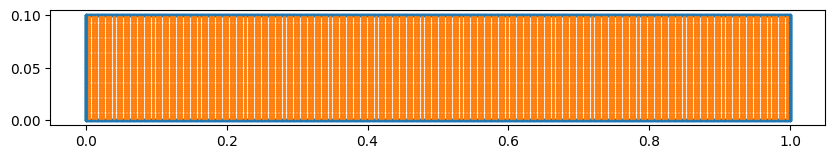

In [ ]:
x0 = 0
y0 = 0
x1 = 1
y1 = 0.1
g = 0 # load

nx = 200      # Points for x-axis
ny = 50      # Points for y-axis
densBnd = 10   # Distribution density of points on boundaries

xnp, ynp = dataPoints(x0,y0,x1,y1,nx,ny,densBnd)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Định nghĩa λ trainable (ban đầu = 1.0)
lambda_pde = nn.Parameter(torch.tensor(1.0, dtype=torch.float32, requires_grad=True).to(device))
lambda_bc  = nn.Parameter(torch.tensor(1.0, dtype=torch.float32, requires_grad=True).to(device))

# Chuyển dữ liệu sang torch và bật requires_grad để tự động đạo hàm
x = torch.tensor(xnp, dtype=torch.float32, requires_grad=True).to(device)
y = torch.tensor(ynp, dtype=torch.float32, requires_grad=True).to(device)

# Lấy chỉ số các mặt biên (đã chia theo load & free nếu muốn)
idxLeft, idxBot, idxTop, idxRight = boundaryPointsCantilever(x,y,x0,y0,x1,y1)

# Khởi tạo mạng
net_u = Net().to(device)
net_v = Net().to(device)

def u_hard(x, y):
    return x * net_u(x, y)

def v_hard(x, y):
    return x * net_v(x, y)  # v(x=0,y,z) = 0

# Cài đặt training
mse = torch.nn.MSELoss()
optimizer_net = torch.optim.Adam(
    list(net_u.parameters()) + list(net_v.parameters()),
    lr=1e-3
)
optimizer_lambda = torch.optim.Adam([lambda_pde, lambda_bc], lr=5e-4)

optimizer_lbfgs = torch.optim.LBFGS(
    list(net_u.parameters()) + list(net_v.parameters()),
    lr=1.0,
    max_iter=5000,
    tolerance_grad=1e-9,
    tolerance_change=1e-12,
    history_size=100,
    line_search_fn='strong_wolfe'
)

history = np.zeros((0, 2))

In [ ]:
import torch
import time

# Huấn luyện PINN 2D
loss_history = []
loss_history_lbfgs = []
lambda_history = []

# Giới hạn lambda để tránh bùng nổ
lambda_min, lambda_max = 1e-2, 100.0

warmup_epochs = 100
num_epochs_adam = 7000
alpha = 0.2

L0_pde, L0_bc = None, None   # loss ban đầu cho GradNorm
start_time = time.time()

for epoch in range(num_epochs_adam):
    t0 = time.time()
    # ================== Update network ==================
    optimizer_net.zero_grad()

    lam_pde = torch.clamp(torch.relu(lambda_pde), lambda_min, lambda_max)
    lam_bc  = torch.clamp(torch.relu(lambda_bc),  lambda_min, lambda_max)

    # Forward lần 1
    mse_losspde = pinnLoss(x, y, mse, net_u, net_v)[0]
    mse_lossbc  = boundaryLoss(g, x, y,
                                 x0, y0, x1, y1,
                                 mse, net_u, net_v)

    if epoch == 0:
        L0_pde = mse_losspde.detach()
        L0_bc  = mse_lossbc.detach()

    loss = lam_pde * mse_losspde + lam_bc * mse_lossbc
    loss.backward()
    optimizer_net.step()

    # ================== Update λ với GradNorm ==================
    if epoch >= warmup_epochs and (epoch % 200 == 0):
        mse_losspde2 = pinnLoss(x, y, mse, net_u, net_v)[0]
        mse_lossbc2  = boundaryLoss(g, x, y,
                                      x0, y0, x1, y1,
                                      mse, net_u, net_v)

        lam_pde2 = torch.clamp(torch.relu(lambda_pde), lambda_min, lambda_max)
        lam_bc2  = torch.clamp(torch.relu(lambda_bc),  lambda_min, lambda_max)

        W = list(net_u.parameters())[0]

        G_pde = torch.autograd.grad(lam_pde2 * mse_losspde2, W,
                                    retain_graph=True, create_graph=True)[0].norm()
        G_bc  = torch.autograd.grad(lam_bc2  * mse_lossbc2, W,
                                    retain_graph=True, create_graph=True)[0].norm()

        G_avg = 0.5 * (G_pde + G_bc)

        r_pde = (mse_losspde2.detach() / L0_pde) / (
                 0.5 * ((mse_losspde2.detach()/L0_pde) + (mse_lossbc2.detach()/L0_bc)))
        r_bc  = (mse_lossbc2.detach() / L0_bc) / (
                 0.5 * ((mse_losspde2.detach()/L0_pde) + (mse_lossbc2.detach()/L0_bc)))

        target_G_pde = G_avg * (r_pde ** alpha)
        target_G_bc  = G_avg * (r_bc ** alpha)

        L_grad = (torch.abs(G_pde - target_G_pde) +
                  torch.abs(G_bc  - target_G_bc))

        optimizer_lambda.zero_grad()
        L_grad.backward()
        optimizer_lambda.step()

    # ================== Logging ==================
    loss_history.append(loss.item())
    lambda_history.append((lam_pde.item(), lam_bc.item()))

    t1 = time.time() - t0

    if (epoch + 1) % 1000 == 0 or epoch == 0:
        print(f"[Epoch {epoch+1:4d}] Total Loss: {loss.item():.4e}")
        print(f"    PDE Loss: {mse_losspde:.4e} | BC Loss: {mse_lossbc:.4e}")
        print(f"    lam_pde={lam_pde.item():.3f}, lam_bc={lam_bc.item():.3f}, time={t1:.2f}s")

adam_time = time.time() - start_time
print(f"===== KẾT THÚC ADAM, Tổng thời gian: {adam_time:.4f}s =====")


In [ ]:
start_lbfgs = time.time()
lbfgs_epoch = 0
loss_history_lbfgs = []

def closure():
    global lbfgs_epoch
    optimizer_lbfgs.zero_grad()

    # freeze lamda sau khi Adam
    lam_pde_val = torch.clamp(torch.relu(lambda_pde.detach()), lambda_min, lambda_max).to(device)
    lam_bc_val  = torch.clamp(torch.relu(lambda_bc.detach()),  lambda_min, lambda_max).to(device)


    # luôn bật grad cho LBFGS
    mse_losspde = pinnLoss(x, y, mse, net_u, net_v)[0]
    mse_lossbc  = boundaryLoss(g, x, y, x0, y0, x1,y1, mse, net_u, net_v)

    loss = lam_pde_val * mse_losspde + lam_bc_val * mse_lossbc
    loss.backward()

    lbfgs_epoch += 1
    loss_history_lbfgs.append(loss.item())

    # if lbfgs_epoch % 1 == 0:
    print(f"[LBFGS step {lbfgs_epoch}] "f"Total={loss.item():.6e}, "f"PDE={mse_losspde.item():.6e}, "f"BC={mse_lossbc.item():.6e}")

    return loss


loss_lbfgs = optimizer_lbfgs.step(closure)

lbfgs_time = time.time() - start_lbfgs
print(f"===== KẾT THÚC L-BFGS, Tổng thời gian: {lbfgs_time:.4f}s =====")
print(f"Final LBFGS loss = {loss_lbfgs.item():.6e}")
# Tổng thời gian huấn luyện Adam + L-BFGS
total_time = time.time() - start_time
print(f"===== Tổng thời gian: {total_time:.4f}s =====")




In [ ]:
def plot_loss(loss_adam, loss_lbfgs=None, ylabel='Training Loss'):
    epochs_adam = len(loss_adam)
    x_adam = np.arange(1, epochs_adam + 1)

    plt.figure(figsize=(8,5))
    plt.plot(x_adam, loss_adam, color='blue', lw=1.5, label='Adam')

    if loss_lbfgs is not None:
        # Trục x liên tục nối liền Adam và L-BFGS
        x_lbfgs = np.arange(epochs_adam + 1, epochs_adam + 1 + len(loss_lbfgs))
        plt.plot(x_lbfgs, loss_lbfgs, color='red', lw=1.5, label='L-BFGS')

    plt.xticks([0, 2000, 4000, 6000, 8000])

    plt.xlabel('Iteration')
    plt.ylabel(ylabel)
    plt.yscale('log')
    plt.tick_params(axis='both', which='minor', length=0)
    plt.legend()
    plt.tight_layout()
    plt.savefig('loss_history.png')
    plt.show()

In [ ]:
# Vẽ biểu đồ
plot_loss(loss_history, loss_lbfgs=loss_history_lbfgs, ylabel='Training Loss')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import torch

# 1. Load dữ liệu FreeFEM++
data = np.loadtxt('/content/freefem_solution_2D.txt')
x_ff, y_ff = data[:,0], data[:,1]
u1_ff, u2_ff = data[:,2], data[:,3]

# 2. Chuyển sang tensor nếu PINN dùng PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_ff_t = torch.tensor(x_ff, dtype=torch.float32, device=device).unsqueeze(-1)
y_ff_t = torch.tensor(y_ff, dtype=torch.float32, device=device).unsqueeze(-1)
# Chuyển dữ liệu chính xác sang tensor
u1_ff_t = torch.tensor(u1_ff, dtype=torch.float32, device=device).unsqueeze(-1)
u2_ff_t = torch.tensor(u2_ff, dtype=torch.float32, device=device).unsqueeze(-1)

# 3. Dự đoán từ PINN
with torch.no_grad():
    u1_pred = net_u(x_ff_t, y_ff_t)  # net_u trả u1
    u2_pred = net_v(x_ff_t, y_ff_t)  # net_v trả u2
pred = torch.cat([u1_pred, u2_pred], dim=1)
exact = torch.cat([u1_ff_t, u2_ff_t], dim=1)

# 4. Tính MSE bằng PyTorch
mse = torch.nn.MSELoss()
mse_val = mse(pred, exact).item()

print(f"MSE Error (u,v): {mse_val:.4e}")

In [ ]:
def get_displacement_field(x, y, net_u, net_v):
    with torch.no_grad():
        u = net_u(x, y)
        v = net_v(x, y)

    x_np = x.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy()
    u_np = u.detach().cpu().numpy()
    v_np = v.detach().cpu().numpy()

    return x_np, y_np, u_np, v_np

In [ ]:
# Compute displacements and deformed coordinates
x_np, y_np, u_np, v_np = get_displacement_field(x, y, net_u, net_v)
x_def_np = x_np + u_np
y_def_np = y_np + v_np

# === Plot Deformed and original shapes ===
plt.figure(figsize=(10, 3))
plt.scatter(x_np, y_np, s=1, label='Original', alpha=0.3)
plt.scatter(x_def_np, y_def_np, s=1, label='Deformed', alpha=0.6)
plt.legend()
plt.title('Deformation of 2D Elastic Beam')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('off')
plt.axis('equal')
plt.grid(True)
plt.show()


In [ ]:
# # Downsample for clarity
stride = 20  # Show every 10th point
x_plot = x_np[::stride]
y_plot = y_np[::stride]
u_plot = u_np[::stride]
v_plot = v_np[::stride]

# # Scale displacement for visibility
scale_factor = 1
u_plot_scaled = u_plot * scale_factor
v_plot_scaled = v_plot * scale_factor

# # Quiver plot
plt.figure(figsize=(20, 6))
plt.quiver(x_plot, y_plot, u_plot_scaled, v_plot_scaled,
            angles='xy', scale_units='xy', scale=1.0, color='blue', width=0.001)
plt.title('Displacement Vector Field (Scaled & Downsampled)')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(True)
plt.show()